# Quickstart: Brightness Temperature

In this notebook, we'll simulate broadband brightness temperatures for various surface temperatures using pyRadtran.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)  # Suppress verbose solver output

config_path = Path('config/velox.yaml')

ds = xr.Dataset(
    coords={
        'time' : '2025-04-04T23:00:00',
        'latitude' : [78.925],
        'longitude' : [12.3747329],
        'altitude' : ('altitude', [0, 10, 100]),
    },
    data_vars={
        'surface_temperature' : [253.15, 263.15, 273.15, 283.15, 293.15],
        'albedo' : [0, 0.25, 0.5, 0.75, 1],
    }
)

ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    albedo_var='albedo',
    parameter_overrides={
        'output_quantity' : 'brightness',
    },
    show_progress=False,
)

print("\nSimulation complete!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")


Simulation complete!
Dataset variables: ['zout', 'lambda', 'eup', 'edn', 'edir']
Dataset coordinates: ['surface_temperature', 'albedo', 'latitude', 'longitude', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'surface_temperature': 5, 'albedo': 5, 'latitude': 1, 'longitude': 1, 'altitude': 3})


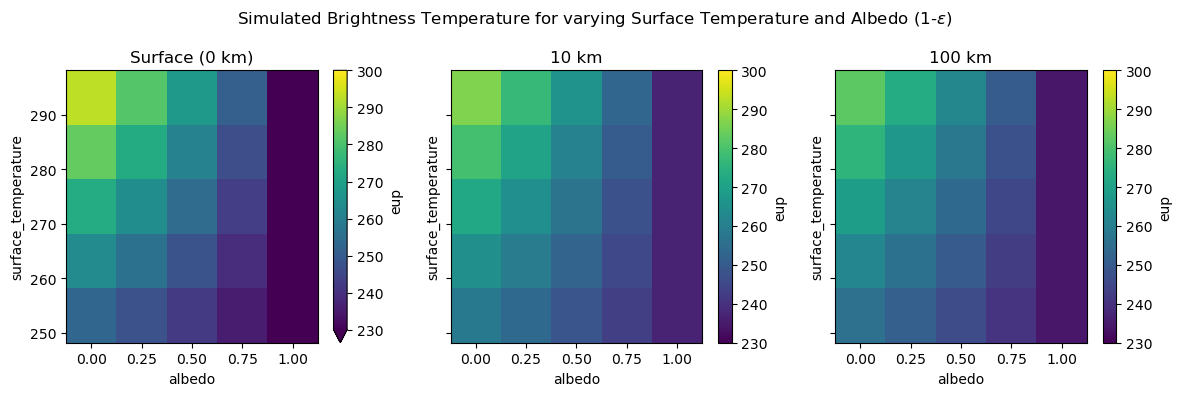

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ds_sim.eup.sel(altitude=0).plot(ax=ax[0], vmin=230, vmax=300)
ds_sim.eup.sel(altitude=10).plot(ax=ax[1], vmin=230, vmax=300)
ds_sim.eup.sel(altitude=100).plot(ax=ax[2], vmin=230, vmax=300)

ax[0].set_title('Surface (0 km)')
ax[1].set_title('10 km')
ax[2].set_title('100 km')

fig.suptitle(r'Simulated Brightness Temperature for varying Surface Temperature and Albedo (1-$\epsilon$)')
plt.tight_layout()

### Key learning

In **libRadtran**, surface emissivity is handled indirectly through **albedo** using the convention:

\[
\epsilon = 1 - \text{albedo}
\]

